# Análisis de valores atípicos de **downtime_gross**

In [641]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [642]:
df = pd.read_parquet('../Dataset limpiado/dataset unificado.parquet')

In [643]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,equipment,6661,int64,"[100268, 100312, 100884, 101632, 101638, 10172..."
1,operation,59,category,"[BIND LEG, BARTACK, SET SLEEVE, TOP STITCH HOO..."
2,wo_type,7,category,"[Corrective Maintenance, Breakdown, Preventati..."
3,base_model,119,category,"[VF2500, LT2-B872, W664, EX5214, VG2700, DLN54..."
4,problem_desc,24,category,"[It sews with defect / Cose con defecto, It do..."
5,failure_desc,38,category,[Machine head failure stopping sewing / Falla...
6,cause_desc,280,category,[Misadjusted machine head teeth / Dientes de c...
7,action_desc,278,category,[Adjust machine head teeth / Ajustar dientes d...
8,mechanic,185,category,"[Jaime Rivera, JERONIMO FUNEZ, Fabit Aranda, C..."
9,date,501,datetime64[ns],"[2023-10-03 00:00:00, 2024-01-17 00:00:00, 202..."


In [644]:
df['base_model'] = df['base_model'].cat.remove_unused_categories()
df['base_model'].value_counts()

base_model
VC2700         17635
FD62           11846
VC1700         11437
VC2713          8374
VG2700          6737
               ...  
VF2529G            2
JK-8670BDII        2
B-100              2
SP161              1
SP172              1
Name: count, Length: 119, dtype: int64

#### Convertimos downtime_gross a minutos

In [645]:
df[['downtime_gross', 'pit_coverage', 'real_downtime', 'repair_hours', 'waiting_hours']].head(5)

,downtime_gross,pit_coverage,real_downtime,repair_hours,waiting_hours
0,75.0,0.0,75.0,75.0,0.0
1,75.0,0.0,75.0,75.0,0.0
2,180.0,180.0,0.0,120.0,60.0
3,15.0,0.0,15.0,15.0,0.0
4,120.0,0.0,120.0,120.0,0.0


In [646]:
if 'downtime_gross_h' not in df.columns:
    df[['downtime_gross_h', 'pit_coverage_h', 'real_downtime_h', 'repair_hours_h', 'waiting_hours_h']] = df[['downtime_gross', 'pit_coverage', 'real_downtime', 'repair_hours', 'waiting_hours']]

df[['downtime_gross', 'pit_coverage', 'real_downtime', 'repair_hours', 'waiting_hours']] = \
                        df[['downtime_gross_h', 'pit_coverage_h', 'real_downtime_h', 'repair_hours_h', 'waiting_hours_h']]*60

df[['downtime_gross', 'pit_coverage', 'real_downtime', 'repair_hours', 'waiting_hours']].head(5)

,downtime_gross,pit_coverage,real_downtime,repair_hours,waiting_hours
0,75.0,0.0,75.0,75.0,0.0
1,75.0,0.0,75.0,75.0,0.0
2,180.0,180.0,0.0,120.0,60.0
3,15.0,0.0,15.0,15.0,0.0
4,120.0,0.0,120.0,120.0,0.0


In [647]:
stats_downtime_gross = df['downtime_gross'].describe().to_frame().T
stats_downtime_gross

,count,mean,std,min,25%,50%,75%,max
downtime_gross,140602.0,90.379539,105.472436,0.0,29.0,50.0,115.0,835.0


In [648]:
media = stats_downtime_gross['mean'][0]
mediana = stats_downtime_gross['50%'][0]

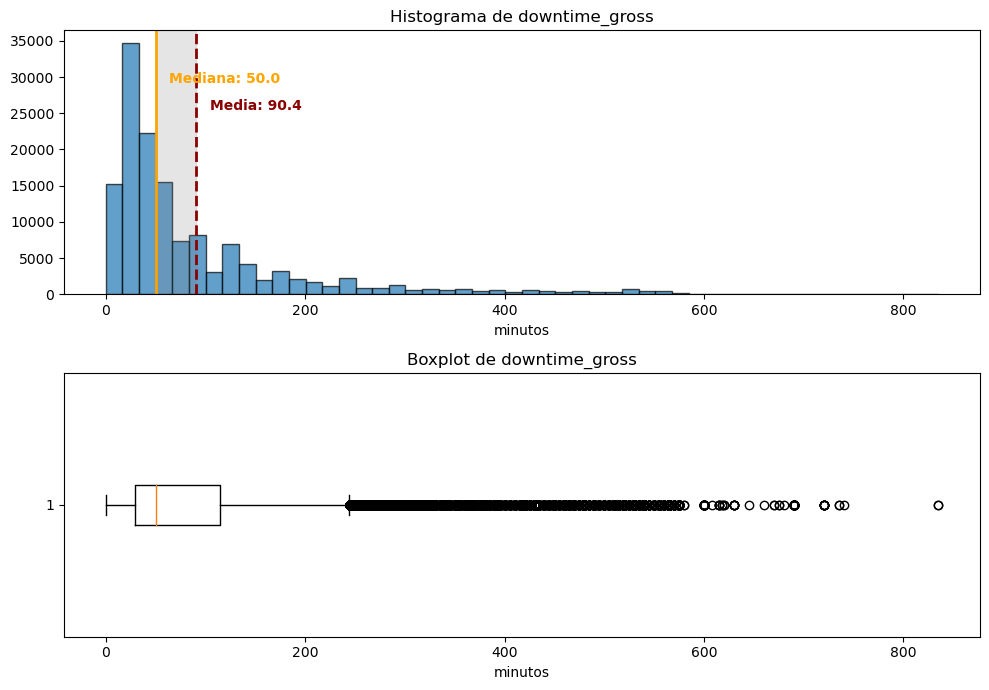

In [649]:
num_intervalos = 50

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Subplot Histograma de downtime_gross
ax1.hist(df['downtime_gross'], bins=num_intervalos, edgecolor='black', alpha=0.7)
ax1.axvline(media, color='darkred', linestyle='--', linewidth=2)
ax1.axvline(mediana, color='orange', linestyle='-', linewidth=2)
ax1.set_title('Histograma de downtime_gross')
ax1.set_xlabel('minutos')
ax1.set_ylabel('')

# Añadir anotaciones
ax1.annotate(f'Media: {media:.1f}', 
            xy=(media, ax1.get_ylim()[1]*0.7),
            xytext=(10, 0), textcoords='offset points',
            fontsize=10, fontweight='bold', color='darkred')
ax1.annotate(f'Mediana: {mediana:.1f}', 
            xy=(mediana, ax1.get_ylim()[1]*0.8),
            xytext=(10, 0), textcoords='offset points',
            fontsize=10, fontweight='bold', color='orange')

# Sombreado entre media y mediana (si hay diferencia)
if media > mediana:
    ax1.axvspan(mediana, media, alpha=0.2, color='gray', label='Diferencia')
else:
    ax1.axvspan(media, mediana, alpha=0.2, color='gray', label='Diferencia')

# Subplot Boxplot de downtime_gross
ax2.boxplot(df['downtime_gross'], vert=False)
ax2.set_title('Boxplot de downtime_gross')
ax2.set_xlabel('minutos')
ax2.set_ylabel('')

plt.tight_layout()

plt.show()

### Definimos outliers por el Rango Intercuartílico (IQR) 

In [650]:
Q1 = df['downtime_gross'].quantile(0.25)
Q3 = df['downtime_gross'].quantile(0.75)
IQR = Q3 - Q1

# El límite superior estándar es Q3 + 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
# limite_superior = df['downtime_gross'].quantile(0.95)

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR', IQR)
print('limite superior:', limite_superior)

Q1: 28.99999998
Q3: 115.00000002
IQR 86.00000004
limite superior: 244.00000008


In [651]:
df['outlier'] = df['downtime_gross'] > limite_superior

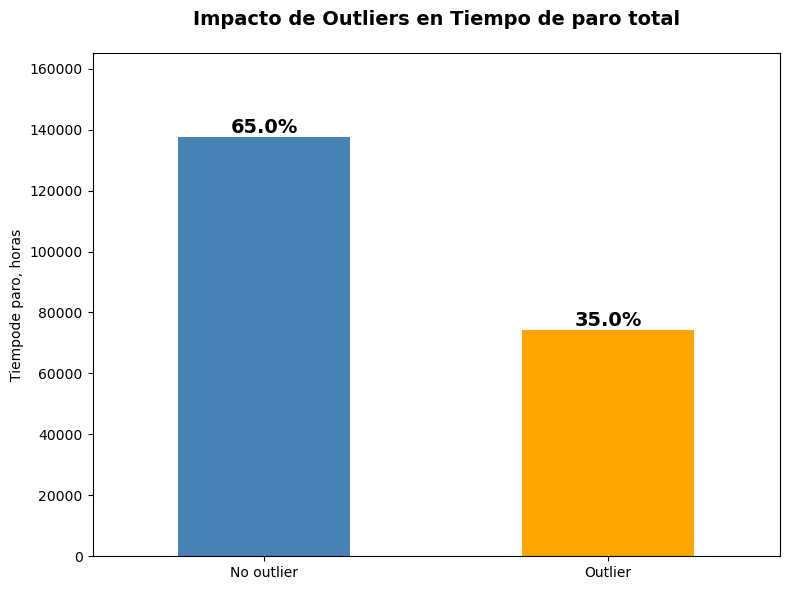

In [652]:
# 1. Preparar los datos
datos = df.groupby('outlier')['downtime_gross_h'].agg(['sum', 'count'])
total_sum = datos['sum'].sum()
datos['porcentaje'] = (datos['sum'] / total_sum) * 100

# 2. Crear el gráfico
ax = datos['sum'].plot.bar(color=['steelblue', 'orange'], figsize=(8, 6))

# 3. Añadir las etiquetas (Número y Porcentaje)
for i, (idx, row) in enumerate(datos.iterrows()):
    # texto = f"Suma: {row['sum']:.1f}h\n({row['count']} casos)\n{row['porcentaje']:.1f}%"
    texto = f"{row['porcentaje']:.1f}%"
    ax.text(i, row['sum'], texto, ha='center', va='bottom', fontsize=14, fontweight='bold')

# Configuración estética
plt.title('Impacto de Outliers en Tiempo de paro total', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Tiempode paro, horas')
plt.xticks([False, True], ['No outlier', 'Outlier'], rotation=0)
plt.ylim(0, datos['sum'].max() * 1.2) # Espacio para las etiquetas
plt.tight_layout()
plt.show()

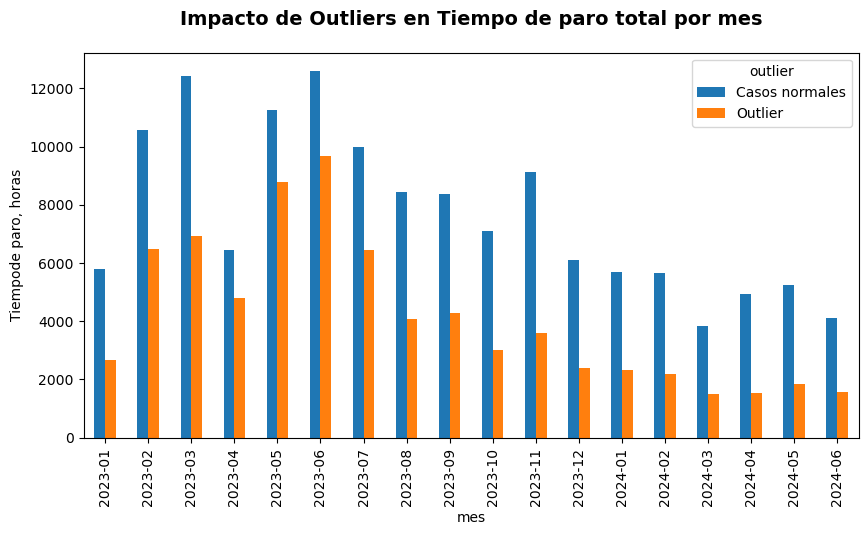

In [653]:
pd.crosstab(df['outlier'], df['mes'], df['downtime_gross_h'], aggfunc='sum').T.\
    rename(columns={False: 'Casos normales', True: 'Outlier'}).\
        plot.bar(figsize=(10,5))

# Configuración estética
plt.title('Impacto de Outliers en Tiempo de paro total por mes', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Tiempode paro, horas')
plt.show()

In [654]:
df_outliers = df[df['outlier'] == True]

### Outliers de **downtime_gross** tiempo de paro por mes y grupo de problema de equipo

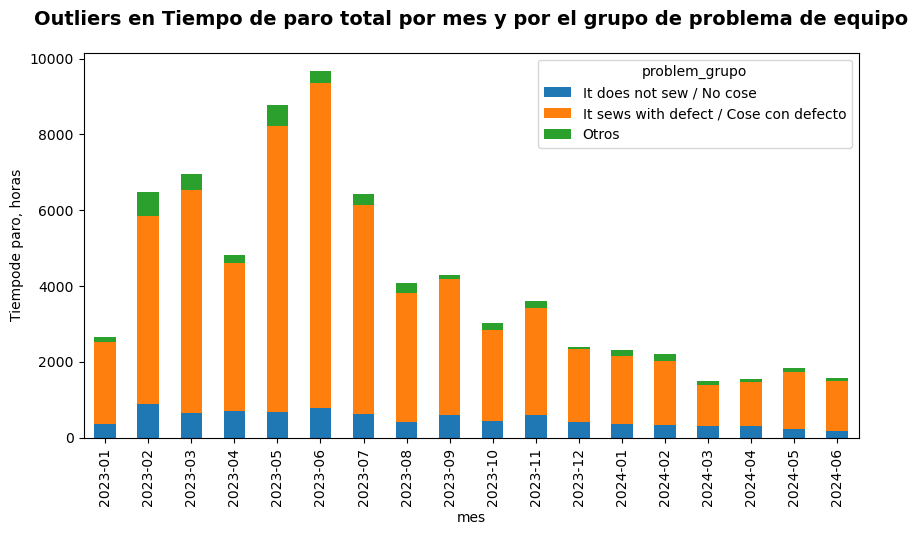

In [655]:
pd.crosstab(df_outliers['mes'], df['problem_grupo'], df['downtime_gross_h'], aggfunc='sum').plot.bar(stacked=True, figsize=(10,5))

# Configuración estética
plt.title('Outliers en Tiempo de paro total por mes y por el grupo de problema de equipo', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Tiempode paro, horas')

plt.show()

### Outliers de tiempo de paro por mes y grupo de fallas

In [656]:
df_outliers_por_mes_grupo_de_fallas = pd.crosstab(df_outliers['mes'], df['falla_grupo'], df['downtime_gross_h'], aggfunc='sum')

In [657]:
color_dict = {
    'Machine head failure stopping sewing  / Falla cabezal dejando de coser': "#1f53b4", 
    'Machine head failure sewing with defect / Falla cabezal cosiendo con defecto': "#c05619c8", 
    'Trim off device failure / Falla dispositivo corta desperdicio': "#2ca07d", 
    'Otros': "#27d6d6" 
    
}
bar_colors = [color_dict.get(grupo) for grupo in df_outliers_por_mes_grupo_de_fallas.columns]
bar_colors

['#c05619c8', '#1f53b4', '#27d6d6', '#2ca07d']

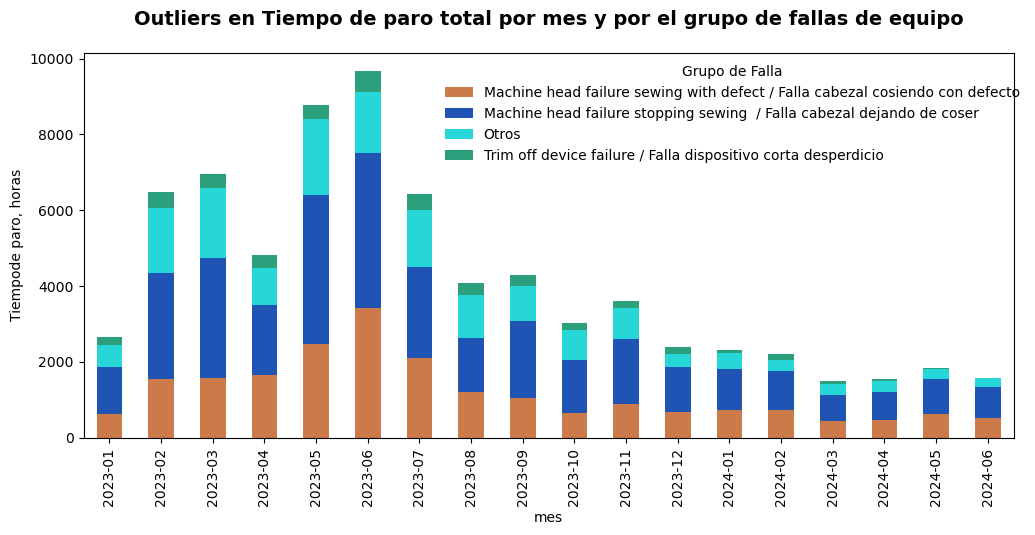

In [658]:
# df_outliers_por_mes_grupo_de_fallas.plot.bar(stacked=True, figsize=(12,5), color=bar_colors)

# Barras horizontales
ax = df_outliers_por_mes_grupo_de_fallas.plot.bar(stacked=True, figsize=(12,5), color=bar_colors)

# Configuración estética
plt.title('Outliers en Tiempo de paro total por mes y por el grupo de fallas de equipo', pad=20, fontsize=14, fontweight='bold')
ax.legend(
    title='Grupo de Falla',
    loc='best',           # Punto de anclaje de la leyenda (esquina sup. izq.)
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)
plt.ylabel('Tiempode paro, horas')

plt.show()

### Outliers de tiempo de paro por mes y **wo_type** tipo de orden de trabajo realizado

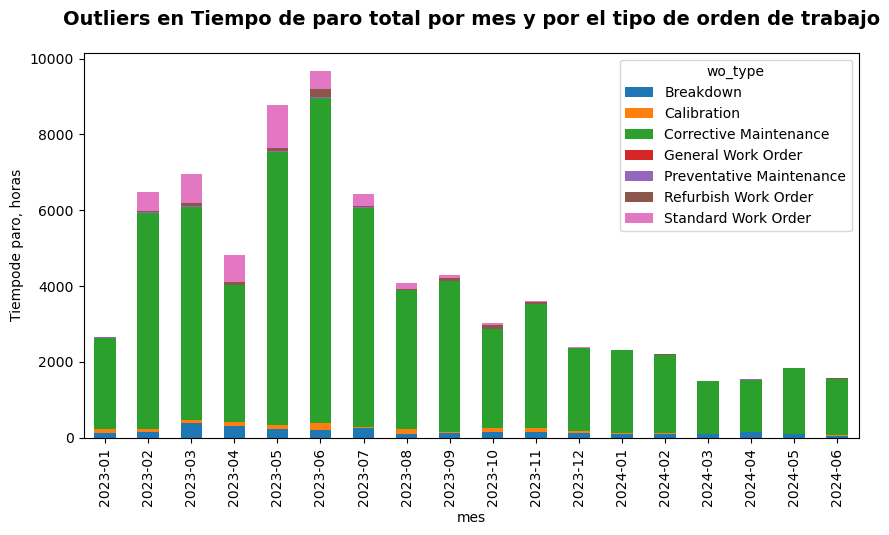

In [659]:
pd.crosstab(df_outliers['mes'], df['wo_type'], df['downtime_gross_h'], aggfunc='sum').plot.bar(stacked=True, figsize=(10,5))

# Configuración estética
plt.title('Outliers en Tiempo de paro total por mes y por el tipo de orden de trabajo', pad=20, fontsize=14, fontweight='bold')
ax.legend(
    title='Grupo de Falla',
    loc='best',           # Punto de anclaje de la leyenda (esquina sup. izq.)
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)

plt.ylabel('Tiempode paro, horas')
plt.show()

### Dispersión de Modelos (Gráfico de dispersión)

- Eje X : Número de máquinas del modelo.

- Eje Y : Suma de tiempo de paro en valores atípicos.

- Tamaño del punto : tiempo de inactividad normal.

In [660]:
df['tiempo_outlier'] = df['downtime_gross_h'].where(df['outlier'], 0)
df['tiempo_normal'] = df['downtime_gross_h'].where(~df['outlier'], 0)


# Agrupar por Modelo Base
analisis_modelos = df.groupby('base_model').agg(
    total_downtime=('downtime_gross_h', 'sum'),
    suma_outliers=('tiempo_outlier', 'sum'),
    suma_normal=('tiempo_normal', 'sum'),
    conteo_outliers=('outlier', 'sum'),
    num_maquinas=('equipment', 'nunique'), 
    antiguedad = ('age', 'mean')
).sort_values('suma_outliers', ascending=False)

analisis_modelos['ratio_critico'] = round((analisis_modelos['suma_outliers'] / analisis_modelos['total_downtime']) * 100, 0)
analisis_modelos[['total_downtime', 'suma_outliers', 'suma_normal']] = analisis_modelos[['total_downtime', 'suma_outliers', 'suma_normal']].astype(int)
analisis_modelos.head(10)


,total_downtime,suma_outliers,suma_normal,conteo_outliers,num_maquinas,antiguedad,ratio_critico
base_model,,,,,,,
VC1700,24041,11323,12717,1770,85,23.226021,47.0
VC2700,27027,10280,16746,1577,400,21.554806,38.0
VC2713,16583,6987,9596,1089,216,22.005135,42.0
FD62,18712,6446,12265,1063,396,21.437194,34.0
VC2711,8712,3199,5513,503,173,21.331940,37.0
VG2735,9941,3071,6870,536,235,21.396574,31.0
VF2403,6788,2812,3975,449,200,19.415718,41.0
C5S-4-M03,7671,2417,5254,389,650,15.214986,32.0
C5-4-M03,5031,1994,3037,313,313,17.128716,40.0


In [670]:
df_plot = analisis_modelos.reset_index().copy()

# Top 10 modelos por suma_outliers
top10 = df_plot.nlargest(10, 'suma_outliers')['base_model']

df_plot['label_top10'] = np.where(df_plot['base_model'].isin(top10),
                                  df_plot['base_model'],
                                  '')


fig = px.scatter(df_plot,
                 width=1000, height=600,
                 x='num_maquinas', 
                 y='suma_outliers',
                 size='suma_normal', 
                 color='ratio_critico',
                 hover_name='base_model',
                 title=f'Análisis de Modelos: Cantidad vs. Impacto de Outliers <br>Número total de Modelos: {df_plot.shape[0]}',
                 labels={'suma_outliers': 'Total Horas en Outliers', 'num_maquinas': 'Cantidad de Máquinas'},
                 text = 'label_top10')

fig.update_layout(
    title={
        'text': f'Análisis de Modelos: Cantidad vs. Impacto de Outliers <br>Número total de Modelos: {df_plot.shape[0]}',
        'font': {'size': 24},
        'x': 0.5,
        'xanchor': 'center'
    }
)
fig.update_traces(textposition='top center')
fig.show()

In [662]:
df['base_model'].nunique

<bound method IndexOpsMixin.nunique of 0              VF2500
1              VF2500
2              VF2500
3            LT2-B872
4            LT2-B872
             ...     
141568      C5S-4-M03
141569      C5S-4-M03
141570      C5S-4-M03
141571    JK-8670BDII
141572    JK-8670BDII
Name: base_model, Length: 140602, dtype: category
Categories (119, object): ['2211EY6701', '504-E256', '504-E51', '504-ETS51', ..., 'W664', 'WT500', 'WT542', 'WT562']>

In [663]:
analisis_modelos.shape

(119, 7)

In [664]:
df_plot

,base_model,total_downtime,suma_outliers,suma_normal,conteo_outliers,num_maquinas,antiguedad,ratio_critico,label_top10
0,VC1700,24041,11323,12717,1770,85,23.226021,47.0,VC1700
1,VC2700,27027,10280,16746,1577,400,21.554806,38.0,VC2700
2,VC2713,16583,6987,9596,1089,216,22.005135,42.0,VC2713
3,FD62,18712,6446,12265,1063,396,21.437194,34.0,FD62
4,VC2711,8712,3199,5513,503,173,21.331940,37.0,VC2711
...,...,...,...,...,...,...,...,...,...
114,SP161,3,0,3,0,1,26.000000,0.0,
115,SP172,0,0,0,0,1,27.000000,0.0,
116,AZ8420,9,0,9,0,2,6.500000,0.0,
117,AZ8203,4,0,4,0,1,9.000000,0.0,


- #### Modelos base "Estables" (Puntos pequeños cerca del origen): modelos de referencia con mejor desempeño.

- #### Puntos altos y grandes de tamañao significa que modelos tienen sumas masivas de horas de inactividad en la cola larga y un tiempo total de inactividad total (normal más valores atipicos) muy elevado. <br>Son los candidatos número uno para una sustitución tecnológica o un cambio radical en el plan de mantenimiento.

- #### Puntos medios y que estan por debajo de 4 grandes y altos. Son modelos para monitoreo preventivo normal. <br>Pueden "saltar" y convertirse en valores atípicos rápidamente debido al desgaste por uso constante.


In [665]:
# 3. Agrupar por Modelo Base
top_10_modelos = df_outliers.groupby('base_model').agg(
    horas_totales_outlier=('downtime_gross_h', 'sum'),
    cantidad_eventos=('downtime_gross_h', 'count'),
    promedio_downtime=('downtime_gross_h', 'mean')
).sort_values('horas_totales_outlier', ascending=False).head(10)

# 4. Calcular peso sobre el total de la cola
total_cola = df_outliers['downtime_gross_h'].sum()
top_10_modelos['%_peso_en_cola'] = (top_10_modelos['horas_totales_outlier'] / total_cola) * 100

print(f"Umbral de outliers: {limite_superior / 60:.2f} h")
top_10_modelos

Umbral de outliers: 4.07 h


,horas_totales_outlier,cantidad_eventos,promedio_downtime,%_peso_en_cola
base_model,,,,
VC1700,11323.900000,1770,6.397684,15.278861
VC2700,10280.516667,1577,6.519034,13.871068
VC2713,6987.000000,1089,6.415978,9.427265
FD62,6446.933333,1063,6.064848,8.698576
VC2711,3199.333333,503,6.360504,4.316726
VG2735,3071.550000,536,5.730504,4.144313
VF2403,2812.500000,449,6.263920,3.794788
C5S-4-M03,2417.433333,389,6.214482,3.261741
C5-4-M03,1994.166667,313,6.371140,2.690645


### Pareto de modelos base en la "cola larga"

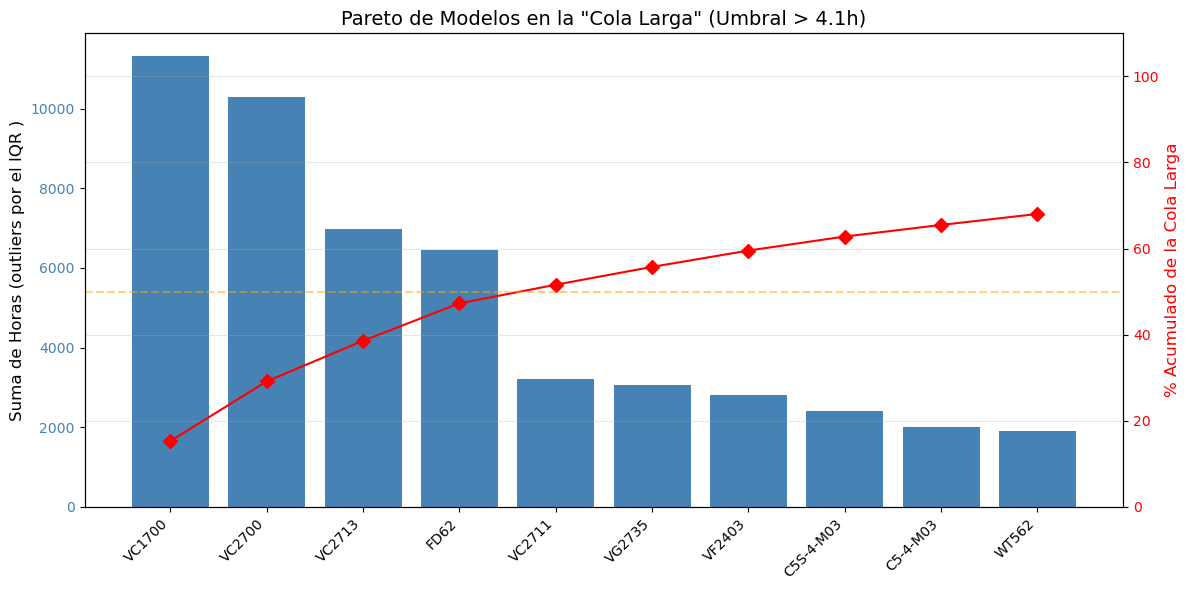

In [666]:
pareto_data = df_outliers.groupby('base_model')['downtime_gross_h'].sum().sort_values(ascending=False).head(10)

# 3. Cálculos para el Pareto
df_pareto = pareto_data.to_frame()
df_pareto['cum_sum'] = df_pareto['downtime_gross_h'].cumsum()
df_pareto['cum_perc'] = 100 * df_pareto['cum_sum'] / df_outliers['downtime_gross_h'].sum()

# 4. Crear el Gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras (Impacto individual)
ax1.bar(df_pareto.index, df_pareto['downtime_gross_h'], color='steelblue', label='Horas Downtime')
ax1.set_ylabel('Suma de Horas (outliers por el IQR )', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45, ha='right')

# Línea (Porcentaje acumulado)
ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cum_perc'], color='red', marker='D', ms=7, label='% Acumulado')
ax2.axhline(50, color='orange', linestyle='--', alpha=0.5) # Línea guía del 50%
ax2.set_ylabel('% Acumulado de la Cola Larga', color='red', fontsize=12)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Pareto de Modelos en la "Cola Larga" (Umbral > {limite_superior / 60:.1f}h)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Vemos que los primeros 4 modelos suman más del 50% de outliers de **downtime_gross_h**. 
### No necesita revisar todos 119 modelos, solo esos 4.


## Guardamos dataset de fallos con nueva variable **outlier**.

In [667]:
df.to_parquet('../Dataset limpiado/dataset unificado.parquet')